In [659]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from scipy.stats import kstest, norm
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

EDA

In [660]:
df = pd.read_csv('ToyotaCorolla.csv')
print("Размер датасета")
df.shape

Размер датасета


(1436, 39)

In [680]:
print("Типы данных")
df.describe

Типы данных


<bound method NDFrame.describe of         Id                                              Model  Price  \
0        1      TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500   
1        2      TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750   
2        3      TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950   
3        4      TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950   
4        5        TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750   
...    ...                                                ...    ...   
1431  1438         TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors   7500   
1432  1439  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...  10845   
1433  1440  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   8500   
1434  1441  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   7250   
1435  1442        TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors   6950   

      Age_08_04  Mfg_Month  Mfg_Year     KM Fuel_Type   HP  Met_Color  ...  \
0            23        

In [662]:
print("Пропуски в данных")
df.isnull().sum()

Пропуски в данных


Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

FEATURE ENGINEERING

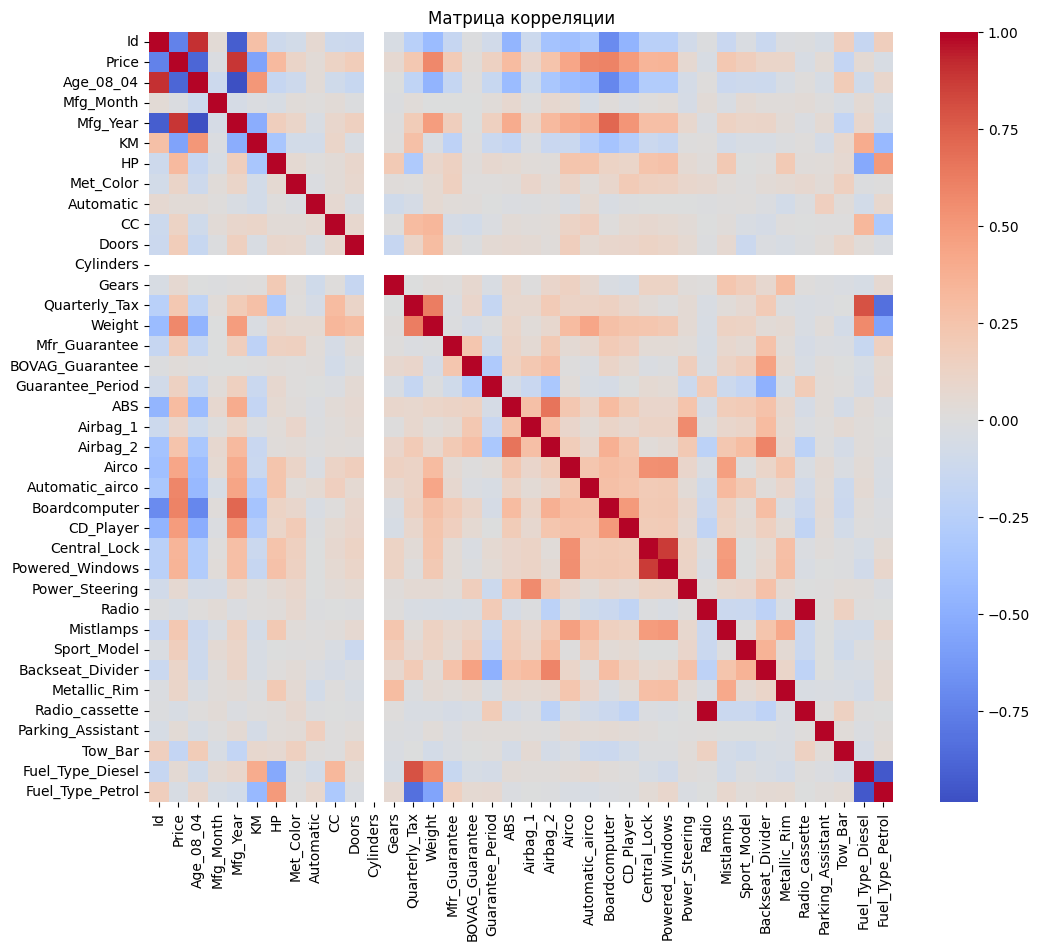

Price                1.000000
Mfg_Year             0.885159
Boardcomputer        0.601292
Automatic_airco      0.588262
Weight               0.581198
CD_Player            0.481374
Airco                0.429259
Powered_Windows      0.356518
Central_Lock         0.343458
HP                   0.314990
ABS                  0.306138
Airbag_2             0.248974
Mistlamps            0.222083
Quarterly_Tax        0.219197
Mfr_Guarantee        0.197802
Doors                0.185326
Sport_Model          0.164121
Guarantee_Period     0.146627
CC                   0.126389
Met_Color            0.108905
Metallic_Rim         0.108564
Backseat_Divider     0.102569
Airbag_1             0.093588
Power_Steering       0.064275
Gears                0.063104
Fuel_Type_Diesel     0.054084
Parking_Assistant    0.044375
Automatic            0.033081
BOVAG_Guarantee      0.028133
Mfg_Month           -0.018138
Fuel_Type_Petrol    -0.038516
Radio               -0.041887
Radio_cassette      -0.043179
Tow_Bar   

In [663]:
#Применяем OneHotEncoder для колонки с типом топлива
df_encoded = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)
#Проверяем корреляцию признаков
corr_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize = (12,10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Матрица корреляции")
plt.show()

print(corr_matrix['Price'].sort_values(ascending=False))

РАЗДЕЛЕНИЕ ВЫБОРКИ

In [664]:
df_encoded = df_encoded.drop(columns=['Model', 'Color'])
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


ОБУЧЕНИЕ МОДЕЛЕЙ

In [665]:
linear_steps = [
    #('scalar', StandardScaler()), # не меняет почти
    #('poly', PolynomialFeatures(degree = 2)), #делает сильно хуже(r2_test = 0.35)
    ('model', LinearRegression())
]
regressor_lin = Pipeline(linear_steps)
regressor_lin.fit(X_train, y_train)

y_pred_lin_train = regressor_lin.predict(X_train)
y_pred_lin_test = regressor_lin.predict(X_test)

r2_train = r2_score(y_train, y_pred_lin_train)
r2_test = r2_score(y_test, y_pred_lin_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred_lin_test))
mape = mean_absolute_percentage_error(y_test, y_pred_lin_test)
cv_lin = cross_val_score(estimator=regressor_lin, X=X_train, y=y_train)

print(f"CV mean = {cv_lin.mean()}")
print(f"R2(train) = {r2_train}" )
print(f"R2(test) = {r2_test}")
print(f"RMSE = {rmse}")
print(f"MAPE = {mape}")


CV mean = 0.7973640457058362
R2(train) = 0.9110367408841208
R2(test) = 0.9057753699247555
RMSE = 1156.3438757784033
MAPE = 0.08290965239352173


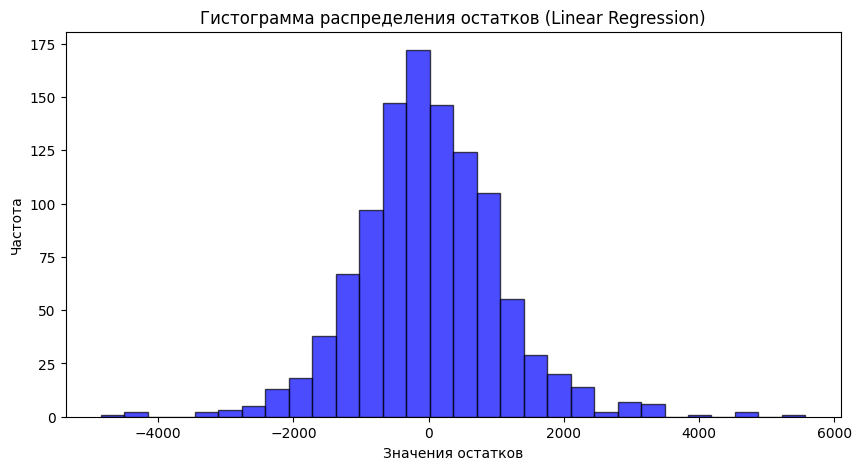

Статистика Колмогорова-Смирнова: 0.0389, P-значение: 7.4366e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


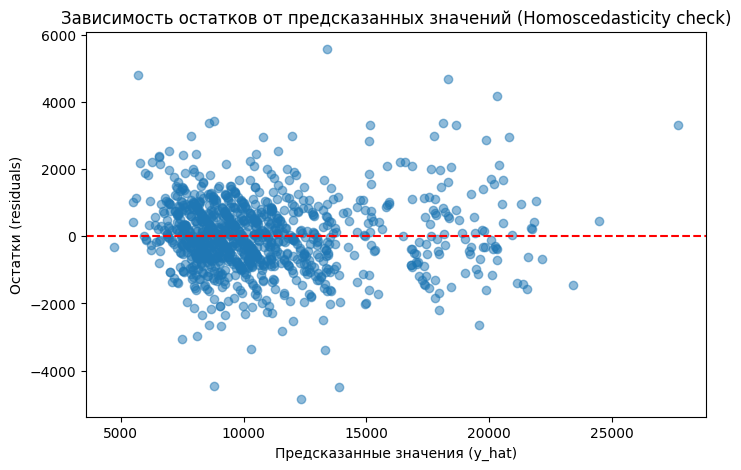

In [666]:
residuals = (y_train-y_pred_lin_train)

def analyze_res(residuals, y_pred):
    plt.figure(figsize=(10,5))
    plt.hist(residuals, bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.title('Гистограмма распределения остатков (Linear Regression)')
    plt.xlabel('Значения остатков')
    plt.ylabel('Частота')
    plt.show()

    residuals_mean = np.mean(residuals)
    residuals_std = np.std(residuals)
    theoretical_distribution = norm(loc=residuals_mean, scale=residuals_std)

    statistic, p_value = kstest(residuals, theoretical_distribution.cdf)
    print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

    alpha = 0.05
    if p_value < alpha:
        print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
    else:
        print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")


    plt.figure(figsize=(8,5))
    plt.scatter(y_pred.ravel(), residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Зависимость остатков от предсказанных значений (Homoscedasticity check)')
    plt.xlabel("Предсказанные значения (y_hat)")
    plt.ylabel("Остатки (residuals)")
    plt.show()
analyze_res(residuals, y_pred_lin_train)

In [676]:
# low corr drop
target_corr = corr_matrix['Price'].abs()
treshold = 0.2 #при меньшем остатки ненормальны
low_corr_cols = target_corr[target_corr<=treshold].index.tolist()

print(f"Признаки с корреляцией < {treshold} по модулю: {low_corr_cols}")

if len(low_corr_cols)>0:
    X_drop = df_encoded.drop(columns=['Price']+low_corr_cols)
    X_drop_train, X_drop_test, y_drop_train, y_drop_test = train_test_split(X_drop, y, test_size=0.2, random_state=42)

    lr_drop = LinearRegression()
    lr_drop.fit(X_drop_train, y_drop_train)

    y_drop_pred_train = lr_drop.predict(X_drop_train)
    y_drop_pred = lr_drop.predict(X_drop_test)
    rmse_drop = np.sqrt(mean_squared_error(y_drop_test, y_drop_pred))
    mape_drop = mean_absolute_percentage_error(y_drop_test, y_drop_pred)
    r2_drop = r2_score(y_drop_test,y_drop_pred)

    print(f"RMSE = {rmse_drop}")
    print(f"MAPE = {mape_drop}")
    print(f"R2_Score(test) = {r2_drop}")



Признаки с корреляцией < 0.2 по модулю: ['Mfg_Month', 'Met_Color', 'Automatic', 'CC', 'Doors', 'Gears', 'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'Airbag_1', 'Power_Steering', 'Radio', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette', 'Parking_Assistant', 'Tow_Bar', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']
RMSE = 1165.149441648864
MAPE = 0.08575753354764348
R2_Score(test) = 0.898254162808289


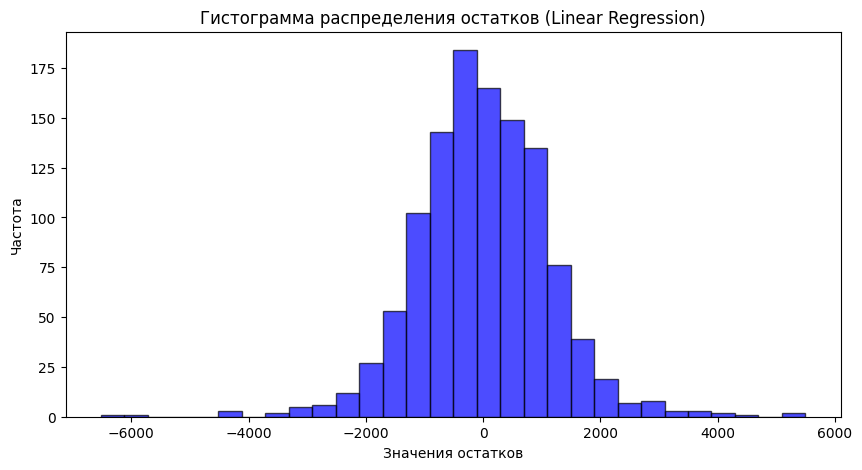

Статистика Колмогорова-Смирнова: 0.0373, P-значение: 8.0003e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


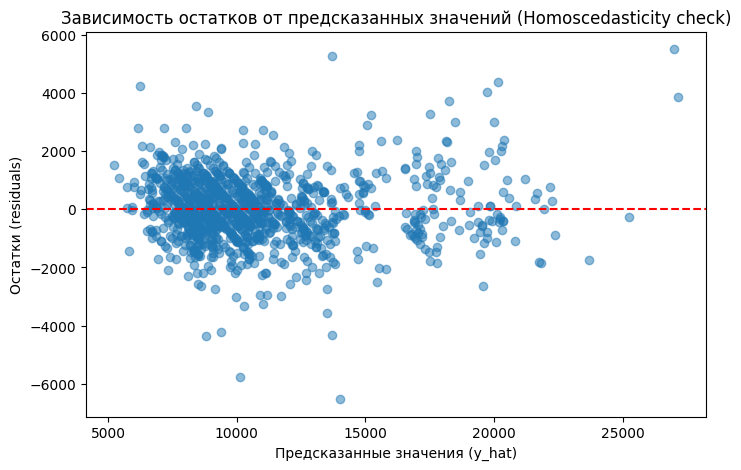

In [668]:
residuals_drop = (y_drop_train-y_drop_pred_train)
analyze_res(residuals_drop, y_drop_pred_train)

In [669]:
ridge_steps = [
    ('scalar', StandardScaler()), # без него результата значительно хуже(r2_test = 0,74)
    ('poly', PolynomialFeatures(degree=2)), # без него гипотеза не принимается
    ('model', Ridge())
]

ridge_pipe = Pipeline(ridge_steps)
ridge_param_grid = {'model__alpha': [0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 2000.0]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_
print(f"Лучшее alpha = {ridge_grid.best_params_['model__alpha']}")

y_pred_ridge_train = best_ridge.predict(X_train)
y_pred_ridge_test = best_ridge.predict(X_test)

r2_ridge_train = r2_score(y_train, y_pred_ridge_train)
r2_ridge_test = r2_score(y_test, y_pred_ridge_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge_test)
cv_ridge = cross_val_score(estimator=best_ridge, X = X_train, y= y_train, cv=10).mean()

print(f"CV mean = {cv_ridge.mean()}")
print(f"R2(train) = {r2_ridge_train}" )
print(f"R2(test) = {r2_ridge_test}")
print(f"RMSE = {rmse_ridge}")
print(f"MAPE = {mape_ridge}")

Лучшее alpha = 100.0
CV mean = -0.3032717508736039
R2(train) = 0.9605054389076857
R2(test) = 0.8415365751651764
RMSE = 1499.5788381231
MAPE = 0.08948472149296098


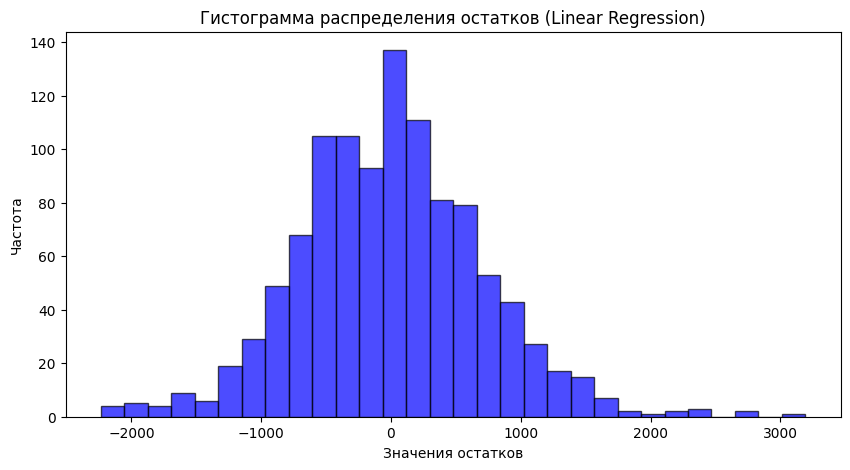

Статистика Колмогорова-Смирнова: 0.0313, P-значение: 2.3839e-01
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


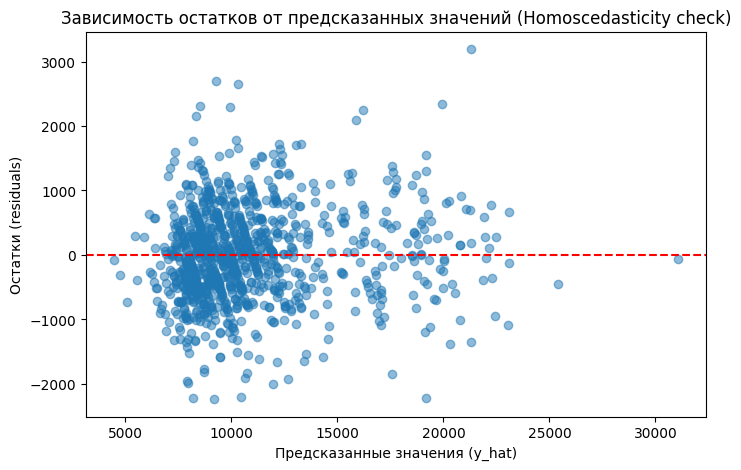

In [670]:
residuals_ridge = (y_train - y_pred_ridge_train)
analyze_res(residuals_ridge, y_pred_ridge_train)

In [674]:
lasso_steps = [
    #('scalar', StandardScaler()), с ним гипотеза не принимается
    #('poly', PolynomialFeatures(degree = 2)), с ним результат хуже
    ('model', Lasso(max_iter=5000))
]
lasso_pipe = Pipeline(lasso_steps)
lasso_param_grid = {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_
print(f"Лучшее alpha = {lasso_grid.best_params_['model__alpha']}")

y_pred_lasso_train = best_lasso.predict(X_train)
y_pred_lasso_test = best_lasso.predict(X_test)

r2_lasso_train = r2_score(y_train, y_pred_lasso_train)
r2_lasso_test = r2_score(y_test, y_pred_lasso_test)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso_test)
cv_lasso = cross_val_score(estimator=best_lasso, X=X_train, y= y_train, cv=10).mean()

print(f"CV mean = {cv_lasso.mean()}")
print(f"R2(train) = {r2_lasso_train}" )
print(f"R2(test) = {r2_lasso_test}")
print(f"RMSE = {rmse_lasso}")
print(f"MAPE = {mape_lasso}")

Лучшее alpha = 10.0
CV mean = 0.8642350603211966
R2(train) = 0.9088233286203352
R2(test) = 0.9063870699973678
RMSE = 1152.5843101117628
MAPE = 0.08266775808011681


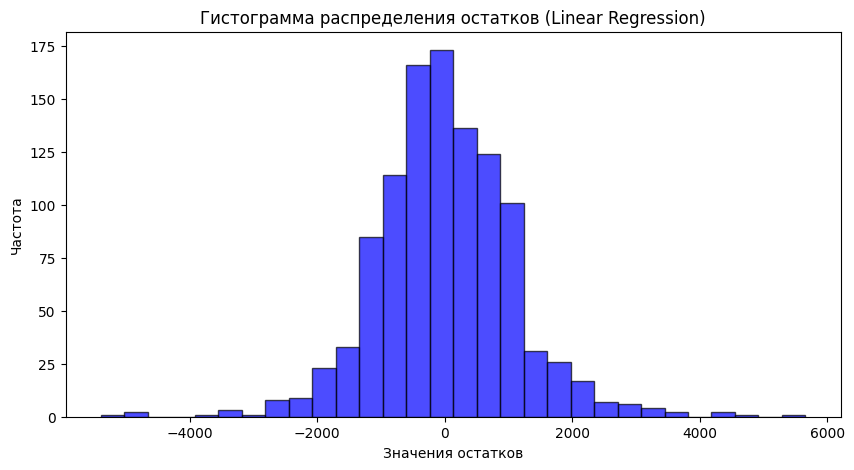

Статистика Колмогорова-Смирнова: 0.0407, P-значение: 5.4597e-02
Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.


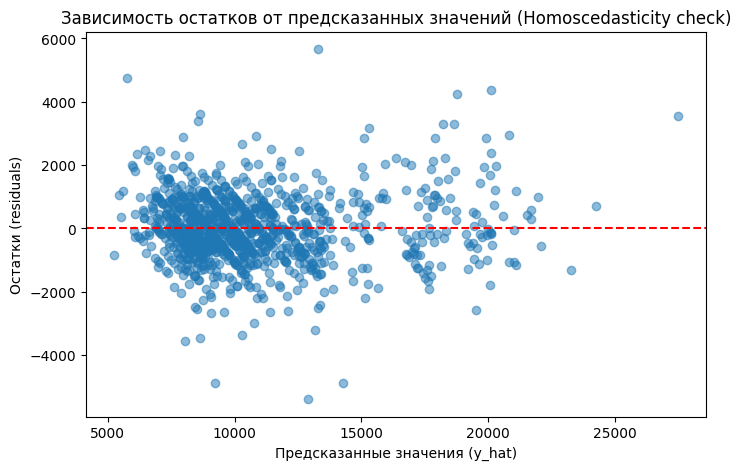

In [672]:
residuals_lasso = (y_train-y_pred_lasso_train)
analyze_res(residuals_lasso, y_pred_lasso_train)

In [678]:
models = [
    ('LinearRegression (Base)', rmse, mape, r2_test),
    ('Drop low corr', rmse_drop if len(low_corr_cols)>0 else None, mape_drop if len(low_corr_cols)>0 else None, r2_drop if len(low_corr_cols)>0 else None),
    ('Ridge', rmse_ridge, mape_ridge, r2_ridge_test),
    ('Lasso', rmse_lasso, mape_lasso, r2_lasso_test)
]

predict_df = pd.DataFrame(data=models, columns=['Model', 'RMSE', 'MAPE', 'R2_Score(test)'])
display(predict_df)

,Model,RMSE,MAPE,R2_Score(test)
0,LinearRegression (Base),1156.343876,0.085758,0.905775
1,Drop low corr,1165.149442,0.085758,0.898254
2,Ridge,1499.578838,0.089485,0.841537
3,Lasso,1152.584310,0.082668,0.906387


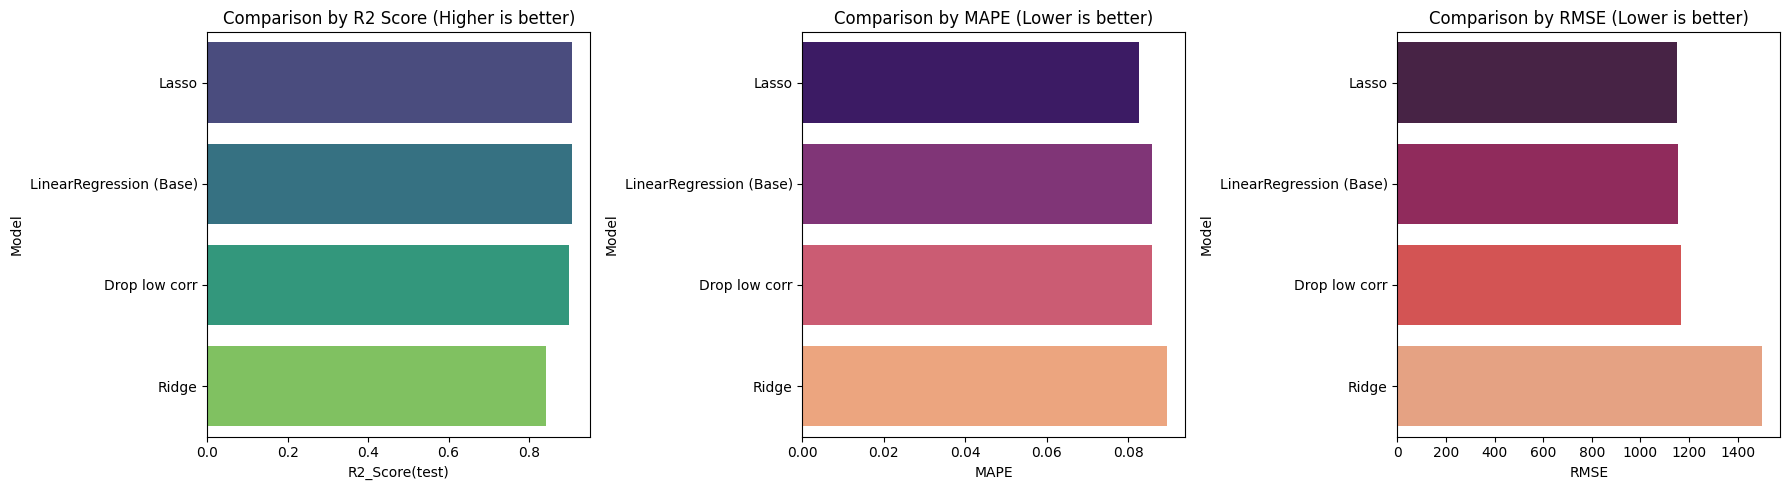

In [679]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False), ax=axes[0], palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAPE', y='Model', data=predict_df.sort_values('MAPE'), ax=axes[1], palette='magma')
axes[1].set_title('Comparison by MAPE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

ИТОГ(Ответы на вопросы)

2. EDA

Как вы предобрабатывали данные?

Проверить типы данных колонок, проверить пропуски

Что вы поняли, проведя EDA?

Датасет чистый(нет пропусков, мало категориальных колонок), удобен для линейной регрессии(но надо немного изменений все таки)

3. Feature Engineering

Как вы работали с признаками?

Какие признаки вы добавили / изменили и почему?

Какие признаки вы удалили и почему?


Применил OneHotEncoder для колонки с типом топлива, чтобы из категориальной колонки сделать 2 числовые

Дропнул колонки модель и цвет, потому что применять какую-то кодировку тяжело, а они при этом слабо коррелируют с ценой

4. Разделение выборки

Как именно вы разделили выборку?

Для чего это нужно?

Разделили на train и test(0.75/0.25)

Нельзя учить и тестить модель на одной выборке, потому чо тогда она будет переобучаться, то есть на этой выборке результат будет хороший, но на новых данных будет хуже

Брать сильно мало данных на тест не стоит, так как тогда модель тоже будет переобучаться

5. Обучение моделей

Как проходило обучение моделей?

Обучили несколько моделей: обычная линейная регрессия, линейная регрессия на данных без слабокоррелирующих колонок, Ridge, Lasso

Обучали через пайплайн, для Ridge и Lasso реализовали подбор гиперпараметра(альфа)


Скорость

На таком небольшом датасете разница в скорости обучения моделей ничтожна, но больше времени занимает только подбор итераций для Lasso

6. Оценка качества и сравнение моделей

Для оценки качества считали RMSE и MAPE(только на тесте), R2(на трейне и на тесте), кроссвалидацию

По итогу лассо справилась лучше всех по каждой метрике

Результат получился хороший:

    по R2 около 0.90

    по MAPE около 8 процентов
    
    по RMSE 1100-1500

Доказали, что модель не переобучилась, сравнив R2 на трейне и тесте, построив гисограмму распределения остатков(нормальная пирамида), кроссвалидация